In [4]:
pip install git+https://github.com/karpathy/micrograd.git

  Cloning https://github.com/karpathy/micrograd.git to /tmp/pip-req-build-hpzdrhrz
  Running command git clone --filter=blob:none --quiet https://github.com/karpathy/micrograd.git /tmp/pip-req-build-hpzdrhrz
  Resolved https://github.com/karpathy/micrograd.git to commit c911406e5ace8742e5841a7e0df113ecb5d54685
  Preparing metadata (setup.py) ... done


In [5]:
from micrograd.engine import Value

In [6]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
e = a*b.relu()+c
f = e**2
g = c + b * a.relu()
g += f
h = 1+c+(-g)
i = h/a

print(f"{i.data:.4f}")
print(a)
i.backward()
print(a)
print(f"{a.grad:.4f}")
print(f"{b.grad:.4f}")
print(f"{c.grad:.4f}")
print(f"{i.data:.4f}")
print(a)
i.backward()
print(a)
print(f"{a.grad:.4f}")
print(f"{b.grad:.4f}")
print(f"{c.grad:.4f}")

-46.5000
Value(data=2.0, grad=0)
Value(data=2.0, grad=24.75)
24.7500
-1.0000
-10.0000
-46.5000
Value(data=2.0, grad=24.75)
Value(data=2.0, grad=81.75)
81.7500
-7.0000
-71.0000


In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
def f(x):
  return 3*x**2 - 4*x + 5

In [9]:
f(2.0)

9.0

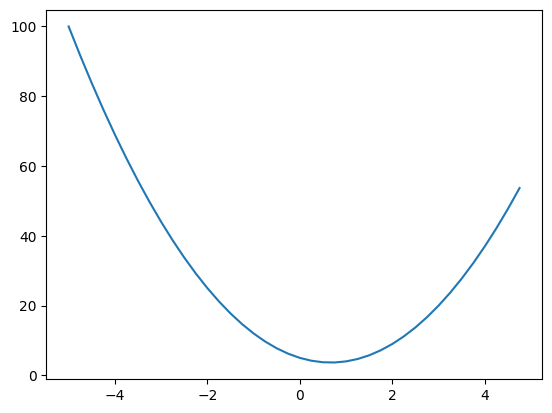

In [10]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [11]:
h=0.00000001
x=2/3
(f(x+h)-f(x))/h

0.0

In [12]:
a=2.0
b=-3.0
c=10.0
d=a*b +c
d

4.0

In [13]:
h=0.0001

a=2.0
b=-3.0
c=10.0

d1=a*b +c
c+=h
d2=a*b+c
print(d1)
print(d2)
print("slope ", (d2-d1)/h)

4.0
4.0001
slope  0.9999999999976694


In [14]:
class Value:

  def __init__(self,data,_children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0
    self._backward = lambda : None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __neg__(self):
    return self * -1

  def __add__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data+other.data,(self,other), '+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __sub__(self,other): # works with just "return self.data+other.data*-1" but i wrote from scratch to help understand
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data*(-1),(self,other), '-')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += -1.0 * out.grad
    out._backward = _backward
    return out

  def __rsub__(self,other):
    return -self + other

  def __mul__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data*other.data,(self,other),'*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __rmul__(self,other):
    return self*other

  def __pow__(self,other): #assumes other is a constant and self is a Value
    assert isinstance(other, (int,float)), f'{other} is not int/float'
    out = Value(self.data**other,(self,),'**')
    def _backward():
      self.grad += (other*(self.data**(other-1))) * out.grad
    out._backward = _backward
    return out

  def __rpow__(self,other): #assumes self is a constant and other is a Value
    assert isinstance(self, (int,float)), f'{self} is not int/float'
    out = Value(self**other.data,(other,),'**')
    def _backward():
      other.grad += (out.data * math.log(self)) * out.grad
    out._backward = _backward
    return out

  def __truediv__(self,other): #again works with a simple return since i have defined * and ** but to help understand wrote from scratch
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data*(other.data**-1),(self,other),'/')
    def _backward():
      self.grad += (other.data**-1) * out.grad
      other.grad += self.data * (-1 * other.data**-2) * out.grad
    out._backward = _backward
    return out

  def __rtruediv__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(other.data*(self.data**-1),(self,other),'/')
    def _backward():
      self.grad += other.data * (-1 * self.data**-2)* out.grad
      other.grad += (self.data**-1)  * out.grad
    out._backward = _backward
    return out

  def exp(self):
    out = Value(math.exp(self.data),(self,), 'exp')
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = (math.exp(self.data)-math.exp((-1)*self.data))/(math.exp(self.data)+math.exp((-1)*self.data))
    out = Value(x, (self,), 'tanh')
    def _backward():
      self.grad += (1 - x**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    #not coded by me
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [15]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [16]:
x1 = Value(2.0, label = 'x1') #input 1
x2 = Value(0.0, label = 'x2') #input 2

w1 = Value(-3.0, label = 'w1') #Weight 1
w2 = Value(1.0, label = 'w2') #Weight 2

b = Value(6.8813735870195432, label = 'b') #Bias [andrej said this number leads to "cleaner outputs" :') ]

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()


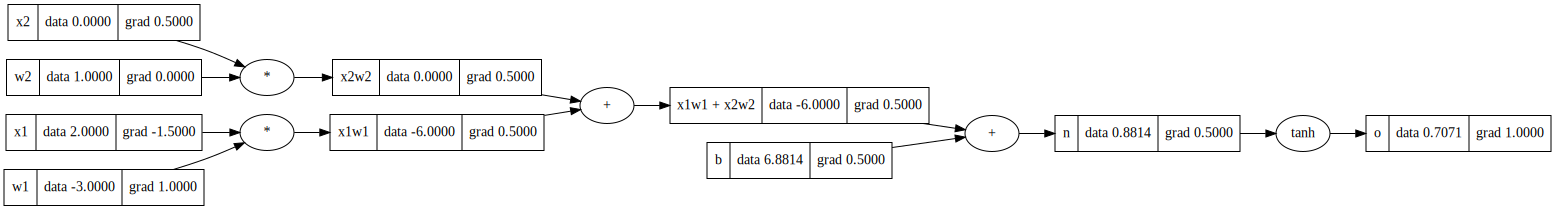

In [17]:
draw_dot(o)

### Derivative of $tanh$(x) is 1-$tanh^2$x

### Since '+' and '-' flow grad directly during backprop (derivative is 1) eg. derivative of $a = b + c$ wrt b is $1 + 0$ and wrt c is $0 + 1$
('-' negates the grad if that variable is negative in the equation)

In [18]:
x1 = Value(2.0, label = 'x1') #input 1
x2 = Value(0.0, label = 'x2') #input 2

w1 = Value(-3.0, label = 'w1') #Weight 1
w2 = Value(1.0, label = 'w2') #Weight 2

b = Value(6.8813735870195432, label = 'b') #Bias [andrej said this number leads to "cleaner outputs" :') ]

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'

o = (n.exp() - (-n).exp()) / (n.exp() + (-n).exp())

o.label = 'o'
o.backward()


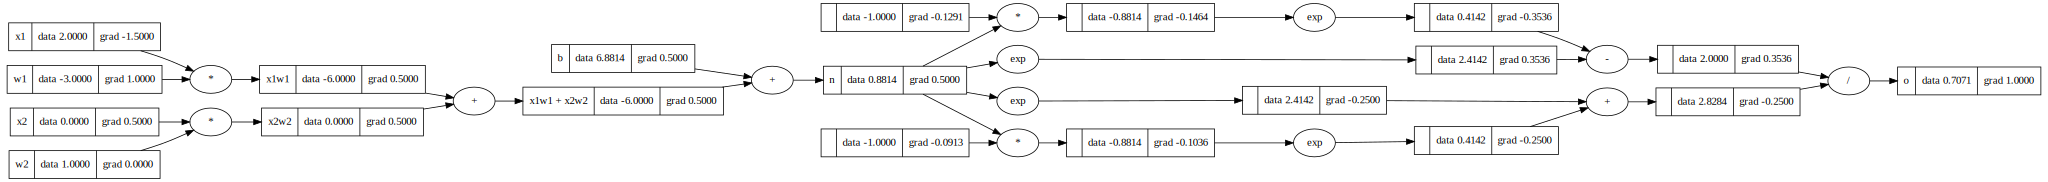

In [19]:
draw_dot(o)

In [20]:
#pytorch implementation:

import torch

x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True

x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True

w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.item()) #apparently modern pytorch does not need .data like andrej did
o.backward()

print('x1 grad ', x1.grad.item())
print('w1 grad ', w1.grad.item())
print('x2 grad ', x2.grad.item())
print('w2 grad ', w2.grad.item())
print('b grad ', b.grad.item())

0.7071066904050358
x1 grad  -1.5000003851533106
w1 grad  1.0000002567688737
x2 grad  0.5000001283844369
w2 grad  0.0
b grad  0.5000001283844369


In [39]:
import random

class Neuron:

  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x): #used when say n(x) is called and n = Neuron(a)
    act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
    return act.tanh()

class Layer:

  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

class MLP:

  def __init__(self, nin, nouts): #n outs is a list with number of neurons in each layer including the output layer. nin is inputs expected
    size = [nin] + nouts #convert nin to list and append it AT THE START of nouts.
    self.layers = [Layer(size[i],size[i+1]) for i in range(len(nouts))] # creates layers expecting size[i] inputs and size[i+1] number of neurons. for every iteration, size[i] is same as size[i+1] for previous iteration.

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=0.7513991528895406)

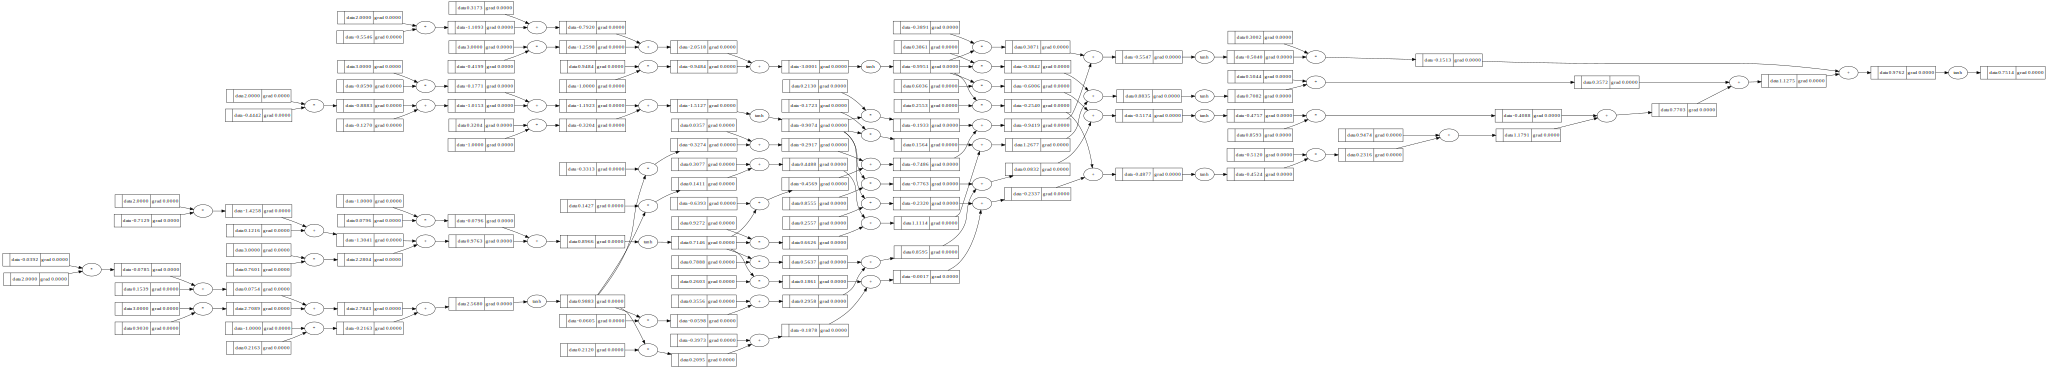

In [40]:
draw_dot(n(x))